In [6]:
import numpy as np
import pickle as pkl

import sys
import torch

sys.path.append("../")
sys.path.append("../../../")
import problem_data as pbd
import utils

In [7]:
results_dir = f"./hpt_results/"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

REPETITIONS = 10

# Hyperparameters
n_hidden_pinn = [1, 2, 3]
hidden_width_pinn = [175, 24, 17]
n_hidden_pikan = [1, 2, 3]
hidden_width_pikan = [23, 7, 5]
G = 5
k = 3

# Reference solution
NUM_X_EVAL = 500
NUM_T_EVAL = 500
x_eval = np.linspace(pbd.INTERVAL_X[0], pbd.INTERVAL_X[1], NUM_X_EVAL)
t_eval = np.linspace(pbd.INTERVAL_T[0], pbd.INTERVAL_T[1], NUM_T_EVAL)
x_eval, t_eval = np.meshgrid(x_eval, t_eval, indexing='ij')
x_eval = x_eval.reshape(-1, 1)
t_eval = t_eval.reshape(-1, 1)

u_true = pbd.u_sol(x_eval, t_eval)
u_grad_true = pbd.u_grad_sol(x_eval, t_eval)
xt_eval_torch = torch.cat(
    (
        torch.tensor(x_eval, dtype=torch.float32, requires_grad=True, device=device),
        torch.tensor(t_eval, dtype=torch.float32, requires_grad=True, device=device)
    ),
    1
)

### Compute errors and select best models

In [3]:
# pinn_summary = utils.summarize_results('PINN', pbd.NUM_INPUTS, pbd.NUM_OUTPUTS, n_hidden_pinn, hidden_width_pinn, xt_eval_torch, u_true, u_grad_true, REPETITIONS, results_dir)

# pikan_summary = utils.summarize_results('PIKAN', pbd.NUM_INPUTS, pbd.NUM_OUTPUTS, n_hidden_pikan, hidden_width_pikan, xt_eval_torch, u_true, u_grad_true, REPETITIONS, results_dir, G, k)

C:\Users\salva\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


In [8]:
with open(results_dir + "PINN/summary.pkl", 'rb') as file:
    pinn_summary = pkl.load(file)
    print("PINN results:")
    utils.print_summary(pinn_summary)

PINN results:
Nº hidden layers: 1 | Hidden layer width: 175 | Nº paramers: 701
    Relative L2 error (mean): 0.5635977684041795%
    Relative L2 error (std): 0.19663138445876677%
    Maximum absolute error (mean): 0.007550230134308668
    Maximum absolute error (std): 0.0018652459103790542
    Relative L2 gradient error (mean): 1.5786936645701064%
    Relative L2 gradient error (std): 0.4414356375971344%
    Maximum absolute gradient error (mean): 0.16223084475616462
    Maximum absolute gradient error (std): 0.057169597584603146
Nº hidden layers: 2 | Hidden layer width: 24 | Nº paramers: 697
    Relative L2 error (mean): 0.5558682399012219%
    Relative L2 error (std): 0.1696725594339398%
    Maximum absolute error (mean): 0.007829357166567906
    Maximum absolute error (std): 0.0017898448943475971
    Relative L2 gradient error (mean): 1.7523947636907589%
    Relative L2 gradient error (std): 0.45500471992920943%
    Maximum absolute gradient error (mean): 0.20058738724860783
    Max

In [9]:
with open(results_dir + "PIKAN/summary.pkl", 'rb') as file:
    pikan_summary = pkl.load(file)
    print("PIKAN results:")
    utils.print_summary(pikan_summary)

PIKAN results:
Nº hidden layers: 1 | Hidden layer width: 23 | Nº paramers: 690
    Relative L2 error (mean): 0.37049901315353695%
    Relative L2 error (std): 0.0004909322254093322%
    Maximum absolute error (mean): 0.006036427617072937
    Maximum absolute error (std): 2.894434786964203e-05
    Relative L2 gradient error (mean): 1.3547310984968082%
    Relative L2 gradient error (std): 0.0014482729721342442%
    Maximum absolute gradient error (mean): 0.21715736322582524
    Maximum absolute gradient error (std): 0.0008276305314999064
Nº hidden layers: 2 | Hidden layer width: 7 | Nº paramers: 700
    Relative L2 error (mean): 0.3055886177863135%
    Relative L2 error (std): 0.0010394956787024084%
    Maximum absolute error (mean): 0.004772522771375476
    Maximum absolute error (std): 3.874428499427862e-05
    Relative L2 gradient error (mean): 1.0354980101840237%
    Relative L2 gradient error (std): 0.0020665181102326046%
    Maximum absolute gradient error (mean): 0.07329555121359

### Plot losses of the best models

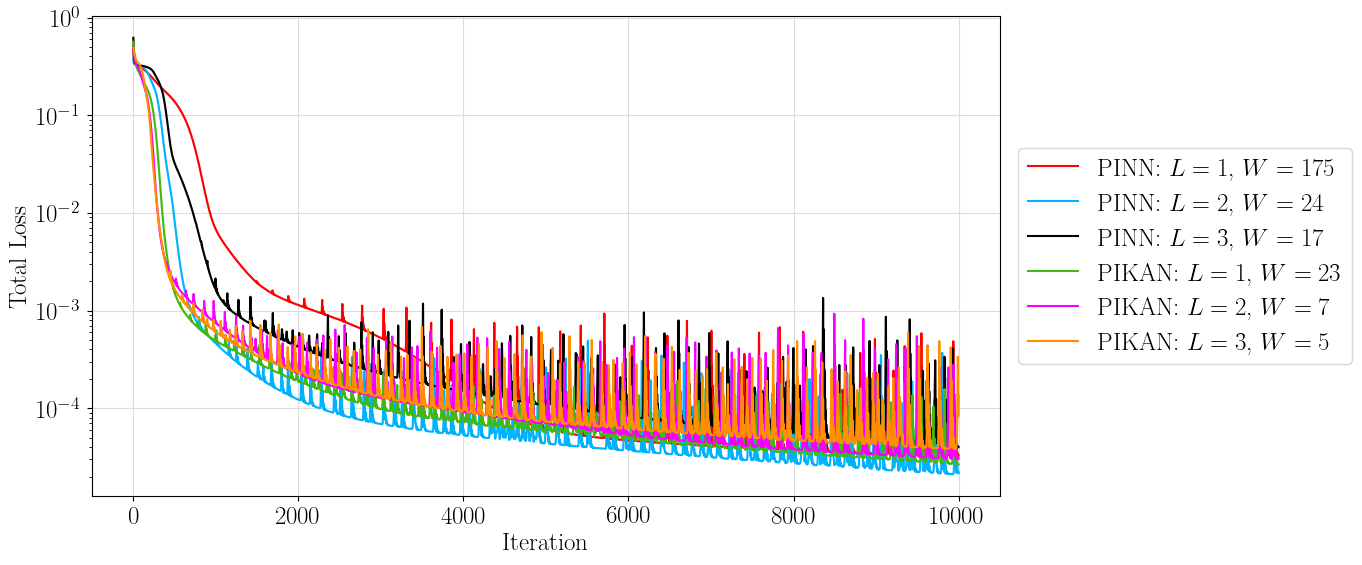

In [10]:
best_pinn_ixs = [pinn_summary[(nh, w)]['lowest_relative_l2_ix'] for nh, w in zip(n_hidden_pinn, hidden_width_pinn)]
best_pikan_ixs = [pikan_summary[(nh, w)]['lowest_relative_l2_ix'] for nh, w in zip(n_hidden_pikan, hidden_width_pikan)]
utils.plot_losses(n_hidden_pinn, hidden_width_pinn, best_pinn_ixs, n_hidden_pikan, hidden_width_pikan, best_pikan_ixs, G, k, results_dir, smoothness=0.)